# Clustering Analysis — Dunnhumby: The Complete Journey
## Household Segmentation for Grocery Retail

**Business Question:** A grocery retailer treats 2,500 loyalty-card households identically across all marketing campaigns. Do natural behavioral groups exist that would justify differentiated strategies?

**Pipeline:** Data Integration → Cleaning → EDA → Feature Engineering (15 features) → Clustering (K-Means, Hierarchical, DBSCAN) → Evaluation (Elbow, Silhouette, ARI) → Profiling → Business Recommendations

GitHub: https://github.com/tvsng23/dunnhumby-grocery-segmentation

Dataset: https://www.kaggle.com/datasets/frtgnn/dunnhumby-the-complete-journey

## 0. Setup

In [106]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [107]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score, adjusted_rand_score)
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# Define the base path for your Google Drive files
PATH = '/content/drive/MyDrive/da_final/dunnhumby/' # Ensure this matches your actual Drive path

# Define the output directory within your Drive path
OUTPUT_DIR = os.path.join(PATH, 'output_files')
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, 'figures'), exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print(f'Pandas {pd.__version__} | NumPy {np.__version__} | Ready')

Pandas 2.2.2 | NumPy 2.0.2 | Ready


## 1. Data Loading & Integration

`transaction_data` is the source of truth. We enrich it with `product` for category/brand information, aggregate campaign exposure and coupon usage per household, and keep `hh_demographic` separate — it covers only ~32% of households and will be used exclusively for post-hoc cluster profiling, not as a clustering input.

`causal_data` (~4M rows) is not used: its in-store display/mailer signals are already partially captured through `discount_rate` and `campaign_exposure_count`, and loading it in full would exhaust Colab memory without adding a distinct behavioral dimension.

In [108]:
PATH = '/content/drive/MyDrive/da_final/dunnhumby/'  # Colab
# PATH = './data/'  # Local

trans    = pd.read_csv(PATH + 'transaction_data.csv')
product  = pd.read_csv(PATH + 'product.csv')
demo     = pd.read_csv(PATH + 'hh_demographic.csv')
camp_t   = pd.read_csv(PATH + 'campaign_table.csv')
coupon_r = pd.read_csv(PATH + 'coupon_redempt.csv')

for name, df in [('transaction_data', trans), ('product', product),
                 ('hh_demographic', demo), ('campaign_table', camp_t),
                 ('coupon_redempt', coupon_r)]:
    nulls = df.isnull().mean().round(3)
    null_str = nulls[nulls > 0].to_dict() if nulls.any() else 'none'
    print(f'{name}: {df.shape[0]:,} rows x {df.shape[1]} cols | nulls: {null_str}')

transaction_data: 2,595,732 rows x 12 cols | nulls: none
product: 92,353 rows x 7 cols | nulls: none
hh_demographic: 801 rows x 8 cols | nulls: none
campaign_table: 7,208 rows x 3 cols | nulls: none
coupon_redempt: 2,318 rows x 4 cols | nulls: none


In [109]:
# Enrich transactions with DEPARTMENT and BRAND from product table.
# Left join preserves all transactions; PRODUCT_ID duplicates in product
# would inflate rows, so we assert shape integrity.
df_trans = trans.merge(
    product[['PRODUCT_ID', 'DEPARTMENT', 'BRAND']],
    on='PRODUCT_ID', how='left'
)
assert df_trans.shape[0] == trans.shape[0], 'Join created duplicate rows — check product table for duplicate PRODUCT_IDs'
print(f'df_trans: {df_trans.shape} | DEPARTMENT null: {df_trans["DEPARTMENT"].isnull().sum()}')

# Campaign exposure: number of distinct campaigns each household was targeted by.
camp_exposure = camp_t.groupby('household_key')['CAMPAIGN'].nunique().rename('campaign_exposure_count')

# Coupon usage: total redemption events per household.
# Households absent from coupon_redempt are genuine non-users — they receive 0.
coupon_usage = coupon_r.groupby('household_key').size().rename('total_redemptions')

print(f'Households with campaign exposure: {len(camp_exposure):,}')
print(f'Households with coupon redemptions: {len(coupon_usage):,}')
print(f'Total households in transactions: {df_trans["household_key"].nunique():,}')

df_trans: (2595732, 14) | DEPARTMENT null: 0
Households with campaign exposure: 1,584
Households with coupon redemptions: 434
Total households in transactions: 2,500


## 2. Data Cleaning

Cleaning decisions follow one principle: preserve analytical integrity without discarding valid behavioral signal.

| Issue | Decision | Rationale |
|---|---|---|
| Duplicate (household, basket, product) rows | Remove | Same product recorded twice in one basket is a data entry artifact |
| SALES_VALUE <= 0 | Inspect count, then remove | Zero/negative values represent returns or voids — not purchasing behavior |
| DEPARTMENT null after join | Retain, flag as 'Unknown' | Product metadata gaps should not bias total spend figures |
| hh_demographic nulls (~40%) | Do not impute; post-hoc use only | Categorical income/marital fields cannot be meaningfully imputed |
| Households with < 4 active weeks | Set spending_trend_slope = 0 | Fewer than 4 weekly data points cannot produce a statistically meaningful OLS trend |

In [110]:
# Duplicate rows
n_dup = df_trans.duplicated(subset=['household_key', 'BASKET_ID', 'PRODUCT_ID']).sum()
print(f'Duplicate (household, basket, product) rows: {n_dup}')
if n_dup > 0:
    df_trans = df_trans.drop_duplicates(subset=['household_key', 'BASKET_ID', 'PRODUCT_ID'])

# Zero / negative SALES_VALUE
n_nonpos = (df_trans['SALES_VALUE'] <= 0).sum()
print(f'Rows with SALES_VALUE <= 0 (returns/voids): {n_nonpos} ({n_nonpos/len(df_trans)*100:.2f}%)')
df_trans = df_trans[df_trans['SALES_VALUE'] > 0].copy()

# Fill unknown department
df_trans['DEPARTMENT'] = df_trans['DEPARTMENT'].fillna('Unknown')

# DAY range used later for recency calculation
MAX_DAY = df_trans['DAY'].max()
print(f'\nAfter cleaning: {df_trans.shape[0]:,} rows | DAY range: {df_trans["DAY"].min()}–{MAX_DAY}')
print(f'Unique households: {df_trans["household_key"].nunique():,}')

# Low-activity households: check how many have very few transactions
hh_counts = df_trans.groupby('household_key').size()
print(f'\nTransaction count per household — min: {hh_counts.min()}, median: {hh_counts.median():.0f}, max: {hh_counts.max()}')
print(f'Households with < 5 transactions: {(hh_counts < 5).sum()}')

Duplicate (household, basket, product) rows: 0
Rows with SALES_VALUE <= 0 (returns/voids): 18850 (0.73%)

After cleaning: 2,576,882 rows | DAY range: 1–711
Unique households: 2,500

Transaction count per household — min: 4, median: 728, max: 6746
Households with < 5 transactions: 1


## 3. Exploratory Data Analysis

EDA here serves one specific purpose: determine whether the data contains sufficient behavioral variance to make clustering meaningful. Each chart tests a specific hypothesis that motivates a downstream feature.

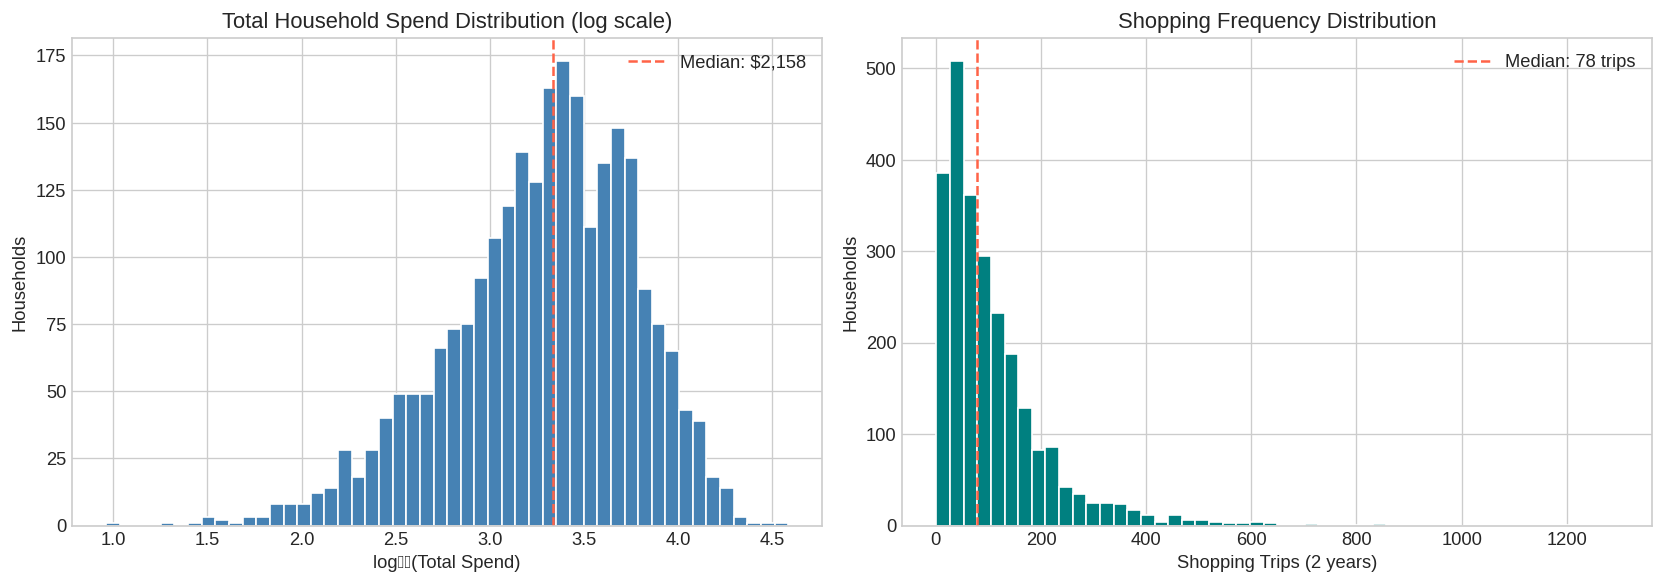

Spend — min: $8, median: $2158, max: $38320
Freq  — min: 1, median: 78, max: 1298


In [111]:
# Hypothesis: household spend and frequency are not uniform — high variance justifies clustering.
hh_spend = df_trans.groupby('household_key')['SALES_VALUE'].sum()
hh_freq  = df_trans.groupby('household_key')['BASKET_ID'].nunique()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log10(hh_spend + 1), bins=50, color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(np.log10(hh_spend.median()), color='tomato', ls='--',
                label=f'Median: ${hh_spend.median():,.0f}')
axes[0].set_xlabel('log\u2081\u2080(Total Spend)')
axes[0].set_ylabel('Households')
axes[0].set_title('Total Household Spend Distribution (log scale)')
axes[0].legend()

axes[1].hist(hh_freq, bins=50, color='teal', edgecolor='white', lw=0.5)
axes[1].axvline(hh_freq.median(), color='tomato', ls='--',
                label=f'Median: {hh_freq.median():.0f} trips')
axes[1].set_xlabel('Shopping Trips (2 years)')
axes[1].set_ylabel('Households')
axes[1].set_title('Shopping Frequency Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '01_spend_frequency_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Spend — min: ${hh_spend.min():.0f}, median: ${hh_spend.median():.0f}, max: ${hh_spend.max():.0f}')
print(f'Freq  — min: {hh_freq.min()}, median: {hh_freq.median():.0f}, max: {hh_freq.max()}')

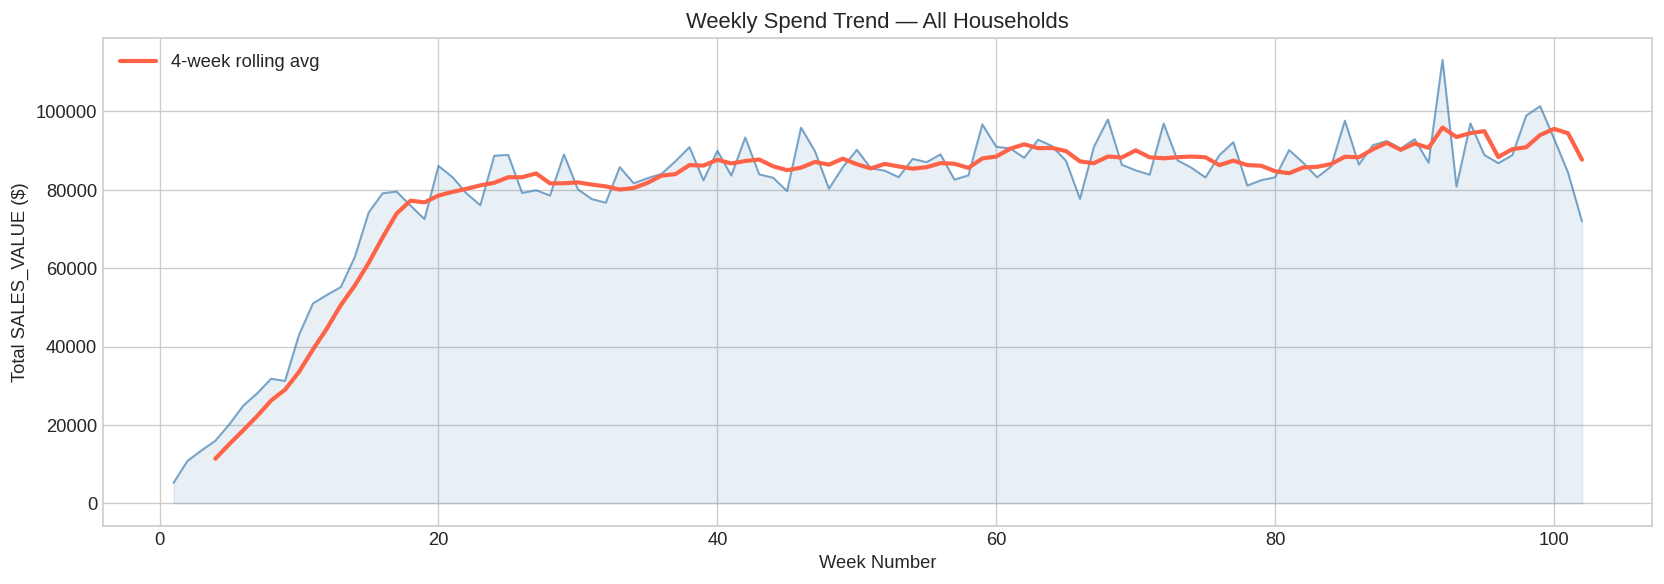

In [112]:
# Hypothesis: aggregate weekly spend has a trend component, validating spending_trend_slope as a feature.
weekly_spend = df_trans.groupby('WEEK_NO')['SALES_VALUE'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_spend.index, weekly_spend.values, color='steelblue', lw=1.2, alpha=0.7)
ax.fill_between(weekly_spend.index, weekly_spend.values, alpha=0.12, color='steelblue')
ax.plot(weekly_spend.rolling(4).mean().index,
        weekly_spend.rolling(4).mean().values,
        color='tomato', lw=2.5, label='4-week rolling avg')
ax.set_xlabel('Week Number')
ax.set_ylabel('Total SALES_VALUE ($)')
ax.set_title('Weekly Spend Trend — All Households')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '02_weekly_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

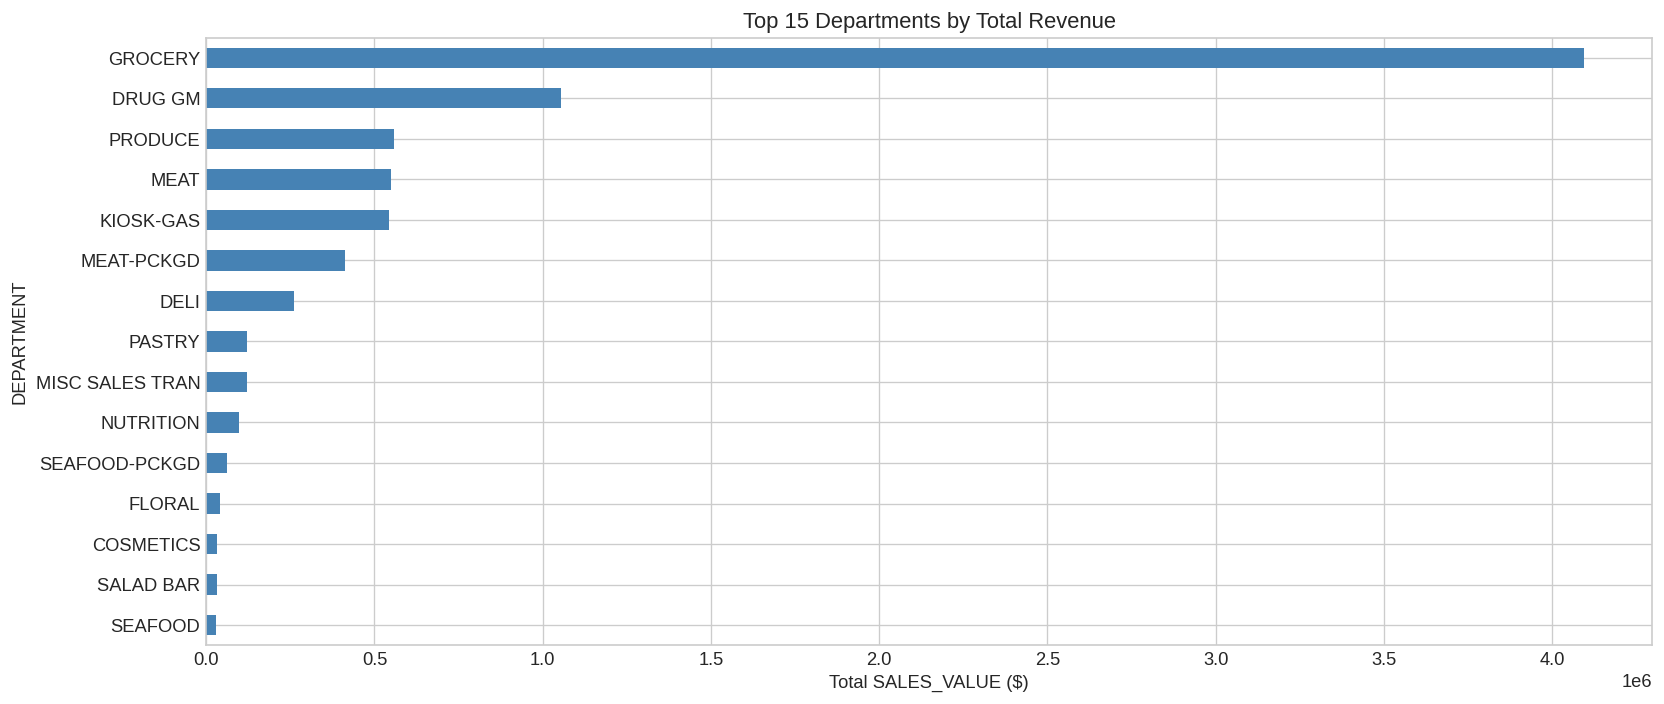

In [113]:
# Hypothesis: spending is concentrated in a few departments, making category_hhi a meaningful
# differentiator between specialist and generalist shoppers.
dept_spend = df_trans.groupby('DEPARTMENT')['SALES_VALUE'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
dept_spend.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_xlabel('Total SALES_VALUE ($)')
ax.set_title('Top 15 Departments by Total Revenue')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '03_department_spend.png'), dpi=150, bbox_inches='tight')
plt.show()

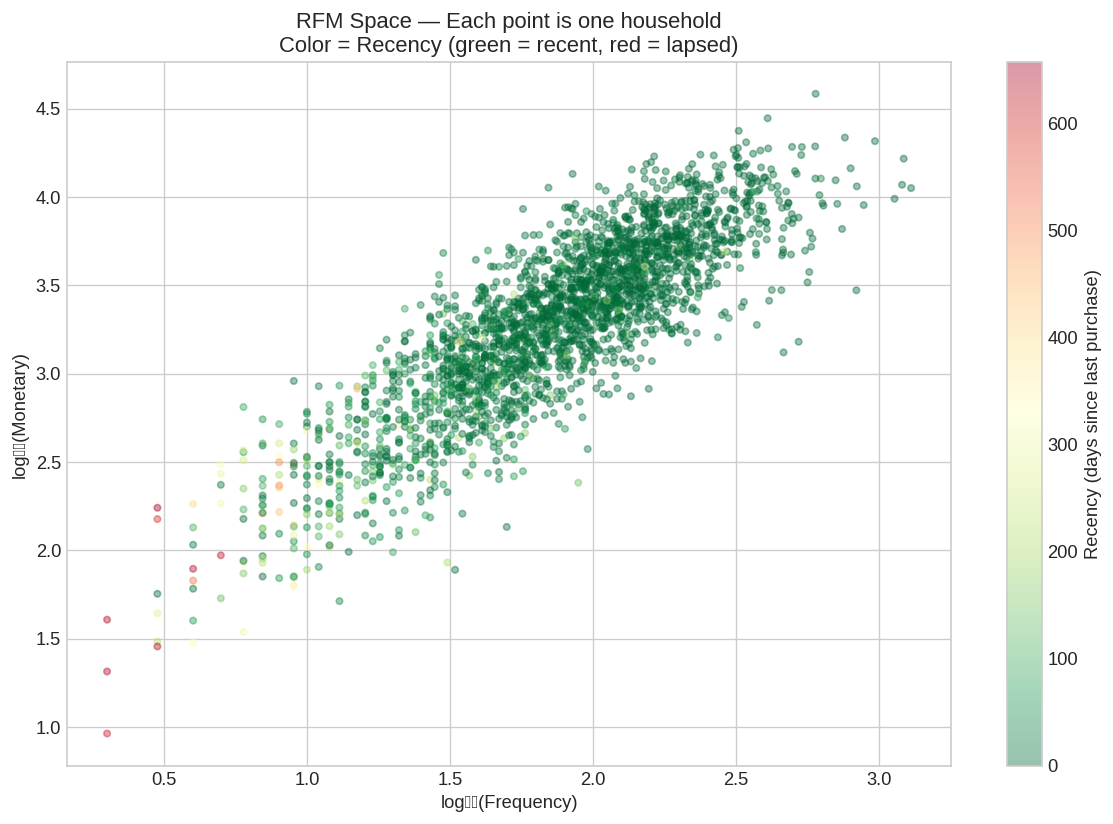

In [114]:
# Hypothesis: households occupy distinct regions of RFM space — visual evidence for cluster structure.
hh_recency = MAX_DAY - df_trans.groupby('household_key')['DAY'].max()

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(np.log10(hh_freq + 1), np.log10(hh_spend + 1),
                c=hh_recency, cmap='RdYlGn_r', alpha=0.4, s=15)
plt.colorbar(sc, label='Recency (days since last purchase)')
ax.set_xlabel('log\u2081\u2080(Frequency)')
ax.set_ylabel('log\u2081\u2080(Monetary)')
ax.set_title('RFM Space — Each point is one household\nColor = Recency (green = recent, red = lapsed)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '04_rfm_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()

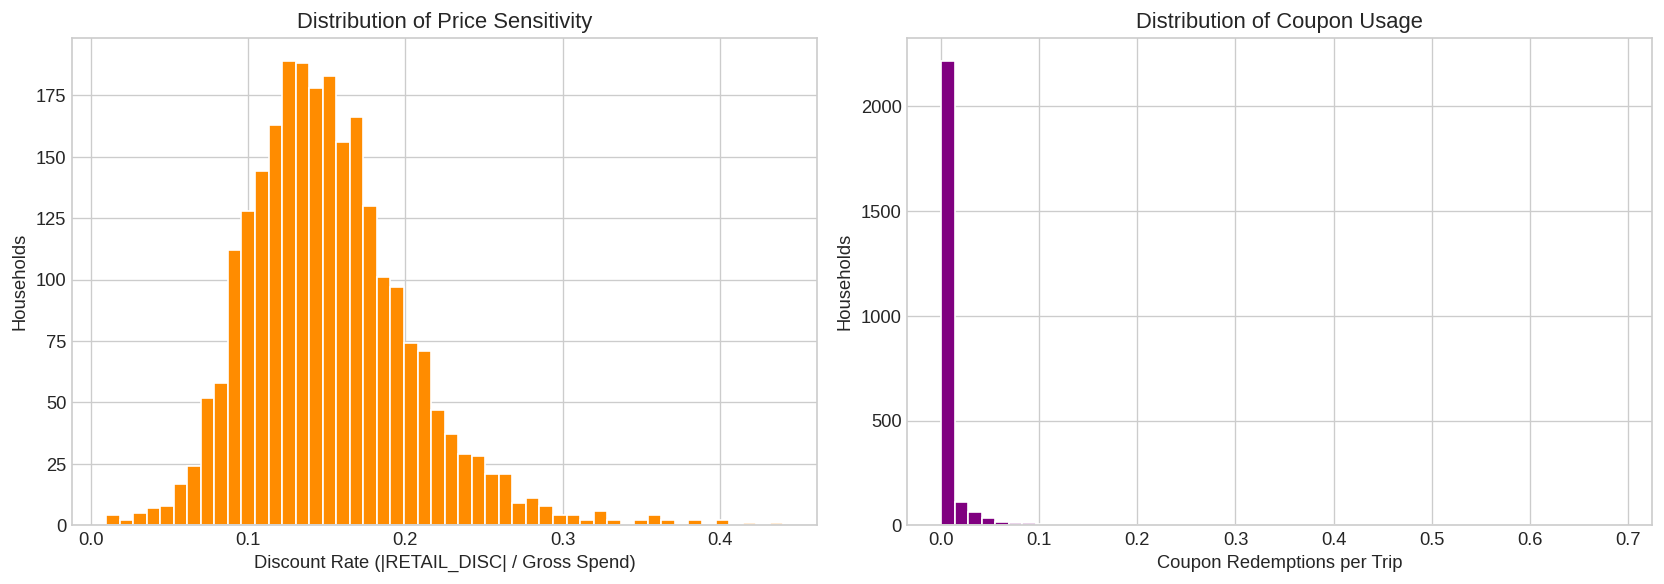

In [115]:
# Hypothesis: promotion sensitivity varies substantially across households,
# justifying discount_rate and coupon_redemption_rate as distinct features.
#
# RETAIL_DISC is stored as a negative value in this dataset (discount subtracted from gross price).
# We take the absolute value before computing rates so all metrics are positive and interpretable.
hh_disc_abs = df_trans.groupby('household_key')['RETAIL_DISC'].sum().abs()
hh_gross    = df_trans.groupby('household_key')['SALES_VALUE'].sum() + hh_disc_abs
hh_discount_rate = (hh_disc_abs / hh_gross.replace(0, np.nan)).fillna(0)

hh_coupon_rate = (coupon_usage / hh_freq).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(hh_discount_rate.clip(0, 1), bins=50, color='darkorange', edgecolor='white', lw=0.5)
axes[0].set_xlabel('Discount Rate (|RETAIL_DISC| / Gross Spend)')
axes[0].set_ylabel('Households')
axes[0].set_title('Distribution of Price Sensitivity')

axes[1].hist(hh_coupon_rate.clip(0, 1), bins=50, color='purple', edgecolor='white', lw=0.5)
axes[1].set_xlabel('Coupon Redemptions per Trip')
axes[1].set_ylabel('Households')
axes[1].set_title('Distribution of Coupon Usage')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '05_promotion_behavior.png'), dpi=150, bbox_inches='tight')
plt.show()

**EDA Conclusion:** Spend and frequency distributions are right-skewed with high variance — the household population is not homogeneous. The RFM scatter shows visual separation hints. Promotion sensitivity varies widely. Temporal trends exist at the aggregate level, suggesting individual trend slopes will carry signal. Clustering is justified. We proceed to construct a 15-feature behavioral vector per household.

## 4. Feature Engineering

15 features organized into 6 MECE groups. Every feature maps directly to an EDA observation.

Two features go beyond standard RFM:
- **`spending_trend_slope`** ★ — OLS slope of a household's weekly spend over 104 weeks. Positive = growing value; negative = churn risk. Entirely absent from standard RFM.
- **`category_hhi`** ★ — Herfindahl-Hirschman Index of spending concentration across departments. HHI=1 means all spend in one category (specialist); near 0 means evenly distributed (generalist). Drives cross-sell strategy.

In [116]:
# basket_totals is the unit of analysis for basket-level features.
# Each row = one basket: total value and the week it occurred.
basket_totals = (
    df_trans.groupby(['household_key', 'BASKET_ID', 'WEEK_NO'])['SALES_VALUE']
    .sum()
    .reset_index()
    .rename(columns={'SALES_VALUE': 'basket_value', 'WEEK_NO': 'basket_week'})
)
print(f'basket_totals: {basket_totals.shape[0]:,} rows (one per basket)')

basket_totals: 275,542 rows (one per basket)


In [117]:
# ── GROUP 1: RFM Core ──
hh_last_day = df_trans.groupby('household_key')['DAY'].max()
recency     = (MAX_DAY - hh_last_day).rename('recency')
frequency   = basket_totals.groupby('household_key')['BASKET_ID'].nunique().rename('frequency')
monetary    = df_trans.groupby('household_key')['SALES_VALUE'].sum().rename('monetary')

# ── GROUP 2: Basket Behavior ──
avg_basket_value = (monetary / frequency).rename('avg_basket_value')
avg_basket_size  = (df_trans.groupby('household_key')['QUANTITY'].sum() / frequency).rename('avg_basket_size')
std_basket_value = basket_totals.groupby('household_key')['basket_value'].std().fillna(0).rename('std_basket_value')

print('Groups 1–2 computed')
print(f'Recency: {recency.min():.0f}–{recency.max():.0f} days')
print(f'Frequency: {frequency.min()}–{frequency.max()} trips')
print(f'Monetary: ${monetary.min():.0f}–${monetary.max():.0f}')

Groups 1–2 computed
Recency: 0–657 days
Frequency: 1–1298 trips
Monetary: $8–$38320


In [118]:
# ── GROUP 3: Category Behavior ──
n_depts = df_trans.groupby('household_key')['DEPARTMENT'].nunique().rename('n_unique_departments')

# category_hhi: vectorized computation avoids a slow Python loop over 2,500 households.
dept_spend_hh = df_trans.groupby(['household_key', 'DEPARTMENT'])['SALES_VALUE'].sum()
shares = dept_spend_hh / dept_spend_hh.groupby(level='household_key').transform('sum')
category_hhi = (shares ** 2).groupby(level='household_key').sum().rename('category_hhi')

national_items       = df_trans[df_trans['BRAND'] == 'National'].groupby('household_key').size()
total_items          = df_trans.groupby('household_key').size()
national_brand_ratio = (national_items / total_items).fillna(0).rename('national_brand_ratio')

print('Group 3 computed')
print(f'HHI range: {category_hhi.min():.3f}–{category_hhi.max():.3f} (1 = pure specialist)')

Group 3 computed
HHI range: 0.153–1.000 (1 = pure specialist)


In [119]:
# ── GROUP 4: Promotion Sensitivity ──
# RETAIL_DISC is negative in the dataset; abs() is required before computing rates.
hh_retail_disc         = df_trans.groupby('household_key')['RETAIL_DISC'].sum().abs()
hh_gross_spend         = monetary + hh_retail_disc
discount_rate          = (hh_retail_disc / hh_gross_spend.replace(0, np.nan)).fillna(0).rename('discount_rate')
coupon_redemption_rate = (coupon_usage / frequency).fillna(0).rename('coupon_redemption_rate')
camp_exp               = camp_exposure.rename('campaign_exposure_count')

print('Group 4 computed')
print(f'Discount rate range: {discount_rate.min():.3f}–{discount_rate.max():.3f}')

Group 4 computed
Discount rate range: 0.010–0.440


In [120]:
# ── GROUP 5: Temporal Patterns ──
active_weeks       = basket_totals.groupby('household_key')['basket_week'].nunique()
total_weeks        = df_trans['WEEK_NO'].nunique()
active_weeks_ratio = (active_weeks / total_weeks).rename('active_weeks_ratio')

# spending_trend_slope: OLS slope of weekly basket spend over the 2-year window.
# The threshold of 4 active weeks ensures the regression is statistically meaningful;
# households below this threshold receive slope = 0 (no detectable trend).
def compute_trend_slope(hh_data):
    weekly = hh_data.groupby('basket_week')['basket_value'].sum().reset_index()
    if len(weekly) < 4:
        return 0.0
    slope, *_ = stats.linregress(weekly['basket_week'], weekly['basket_value'])
    return slope

print('Computing spending trend slopes...')
trend_slopes = (basket_totals.groupby('household_key')
                .apply(compute_trend_slope)
                .rename('spending_trend_slope'))
print(f'Slope range: {trend_slopes.min():.4f}–{trend_slopes.max():.4f}')
print(f'Negative slopes (declining spend): {(trend_slopes < 0).sum()} households')

Computing spending trend slopes...
Slope range: -2.8211–3.1089
Negative slopes (declining spend): 1137 households


In [121]:
# ── GROUP 6: Store Loyalty ──
# primary_store_share: proportion of a household's trips spent at their most-visited store.
# Computed on basket-level visits (not transaction rows) to match the unit of frequency.
store_basket_visits = (
    df_trans.groupby(['household_key', 'STORE_ID'])['BASKET_ID']
    .nunique()
)
primary_store_visits = store_basket_visits.groupby(level='household_key').max()
primary_store_share  = (primary_store_visits / frequency).clip(0, 1).rename('primary_store_share')

print('Group 6 computed')
print(f'Primary store share range: {primary_store_share.min():.3f}–{primary_store_share.max():.3f}')

Group 6 computed
Primary store share range: 0.145–1.000


In [122]:
# Assemble the 15-feature matrix.
# camp_exp and coupon_redemption_rate are reindexed to df_trans households
# and filled with 0 — non-exposure and non-redemption are valid behavioral signals.
all_households = df_trans['household_key'].unique()

df_features = pd.concat([
    recency, frequency, monetary,
    avg_basket_value, avg_basket_size, std_basket_value,
    n_depts, category_hhi, national_brand_ratio,
    discount_rate, coupon_redemption_rate,
    camp_exp.reindex(all_households).fillna(0),
    active_weeks_ratio, trend_slopes,
    primary_store_share
], axis=1).loc[all_households].fillna(0)

# Rename campaign column to match report table
df_features = df_features.rename(columns={'campaign_exposure_count': 'campaign_exposure_count'})

print(f'Feature matrix: {df_features.shape} — expected (2500, 15)')
print(f'Any nulls: {df_features.isnull().sum().sum()}')
print('\nFeature summary:')
print(df_features.describe().round(3))

Feature matrix: (2500, 15) — expected (2500, 15)
Any nulls: 0

Feature summary:
        recency  frequency   monetary  avg_basket_value  avg_basket_size  \
count  2500.000   2500.000   2500.000          2500.000         2500.000   
mean     25.576    110.217   3222.985            31.728          729.525   
std      62.792    115.272   3349.026            19.116         1243.999   
min       0.000      1.000      8.170             2.388            1.594   
25%       1.000     38.000    970.740            18.432           13.542   
50%       6.000     78.000   2157.750            27.489          137.507   
75%      20.000    142.000   4413.320            40.619          966.740   
max     657.000   1298.000  38319.790           165.829        16322.500   

       std_basket_value  n_unique_departments  category_hhi  \
count          2500.000              2500.000      2500.000   
mean             28.765                12.273         0.346   
std              16.241                 3.531 

Correlation pairs > 0.9:
  None — all features sufficiently independent


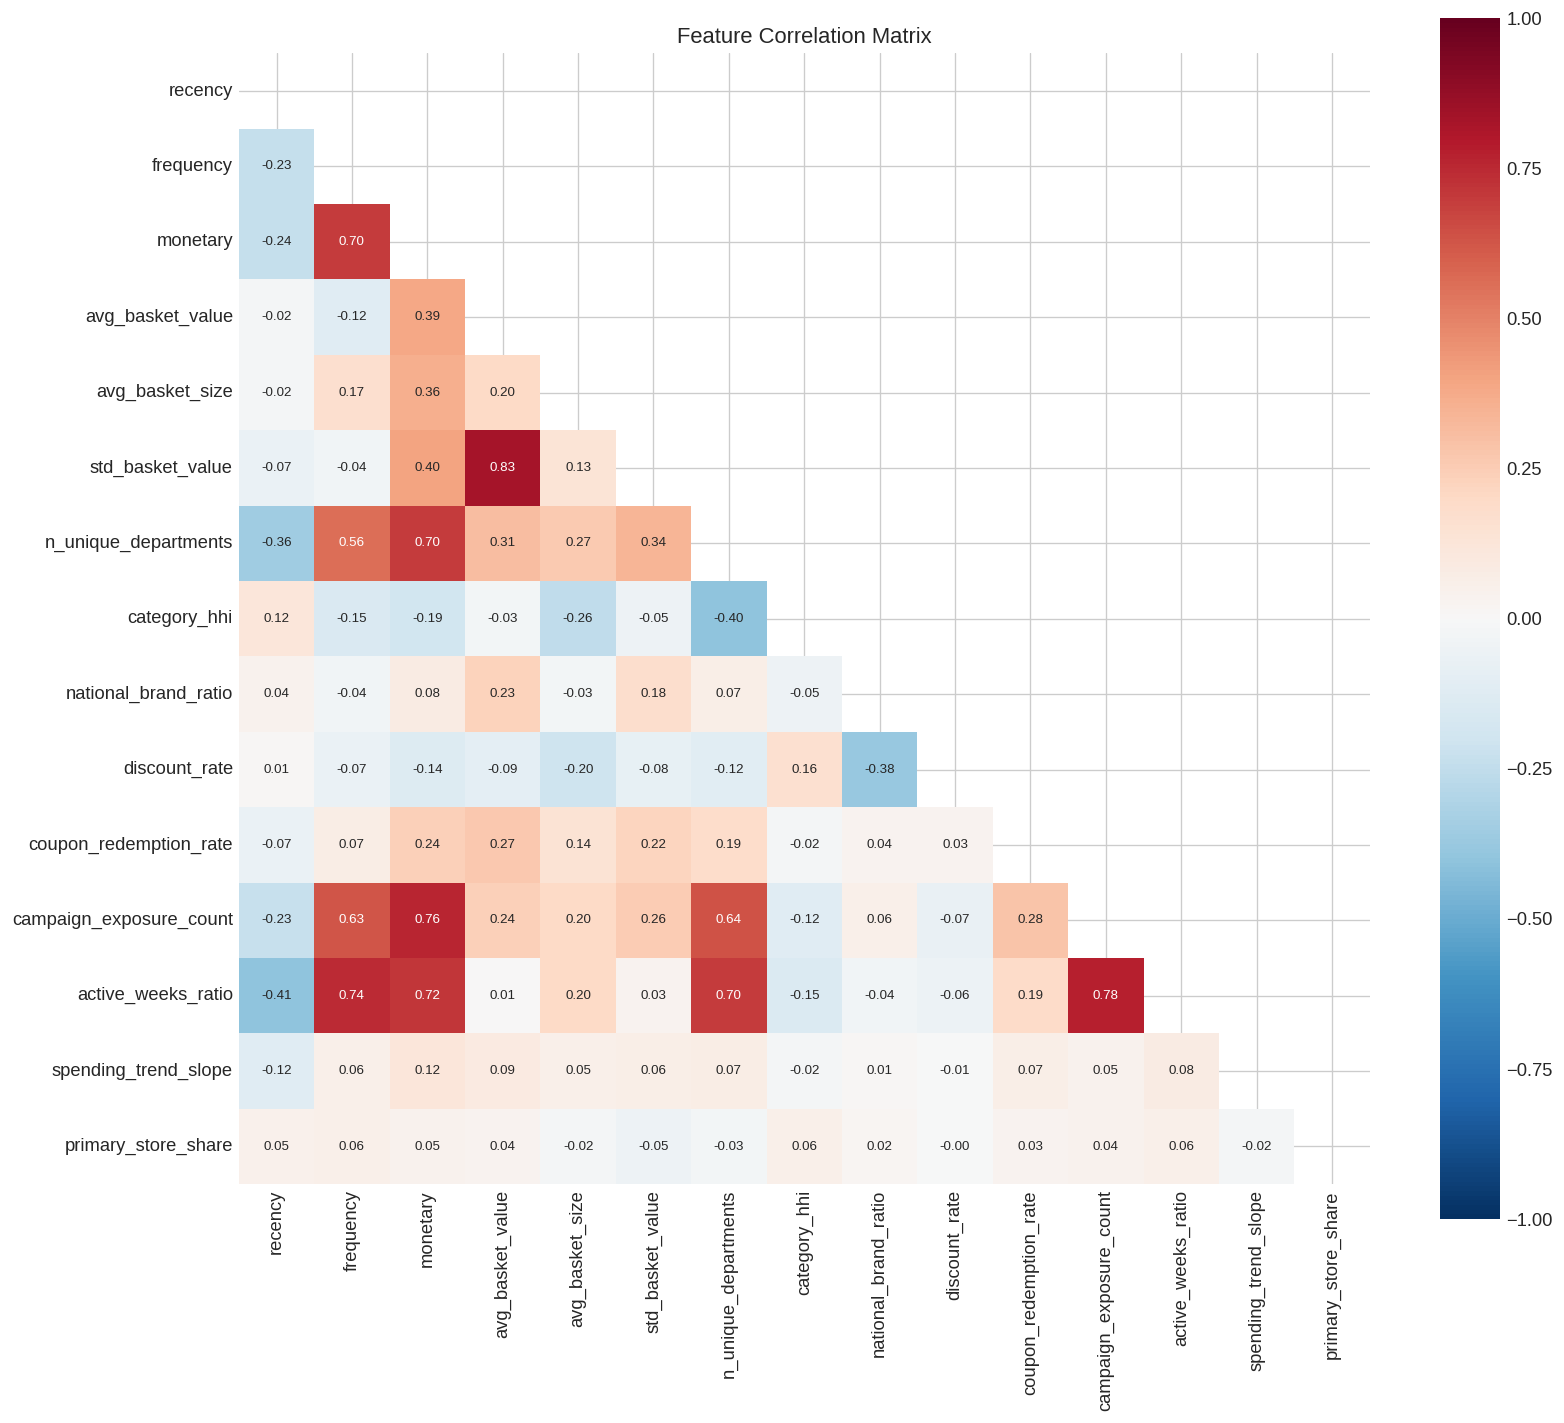

In [123]:
# Check for high correlation pairs (> 0.9) that would indicate redundant features.
corr = df_features.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [(c, r, upper.loc[r, c]) for c in upper.columns for r in upper.index
             if upper.loc[r, c] > 0.9]

print('Correlation pairs > 0.9:')
print(high_corr if high_corr else '  None — all features sufficiently independent')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(df_features.corr(), dtype=bool))
sns.heatmap(df_features.corr(), mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, annot=True, fmt='.2f',
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '06_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

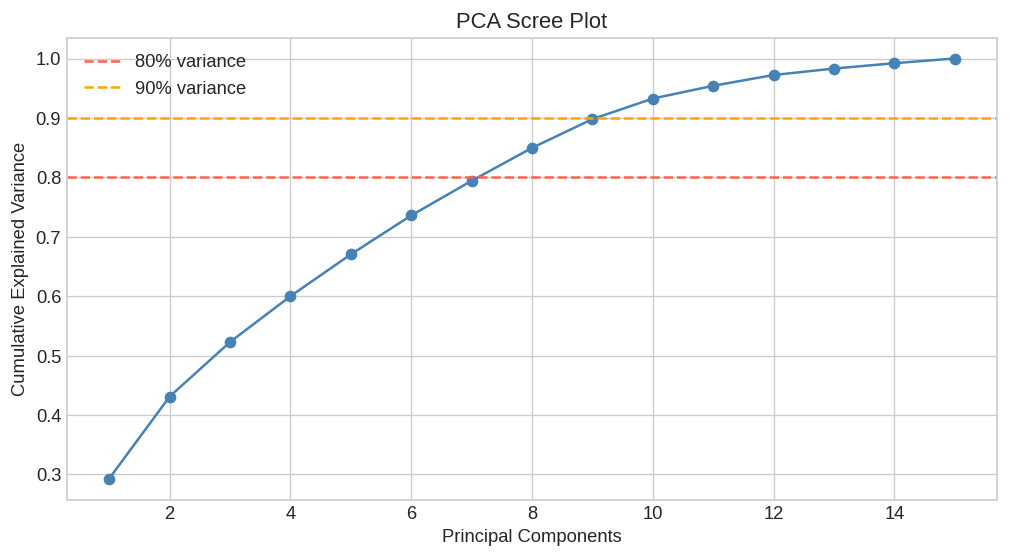

Components to explain 80% variance: 8
Components to explain 90% variance: 10


In [124]:
df_features.to_csv(os.path.join(OUTPUT_DIR, 'df_features.csv'))

# Scale once; all three algorithms receive the same X.
scaler = StandardScaler()
X = scaler.fit_transform(df_features)

# PCA scree: how many dimensions carry meaningful variance?
pca_check = PCA().fit(X)
cumvar = np.cumsum(pca_check.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='steelblue')
ax.axhline(0.80, color='tomato', ls='--', label='80% variance')
ax.axhline(0.90, color='orange', ls='--', label='90% variance')
ax.set_xlabel('Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA Scree Plot')
ax.legend()
ax.grid(True)
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '07_pca_scree.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Components to explain 80% variance: {np.argmax(cumvar >= 0.80) + 1}')
print(f'Components to explain 90% variance: {np.argmax(cumvar >= 0.90) + 1}')

## 5. Clustering

All three algorithms receive the same `X` (StandardScaler-normalized). This ensures any difference in output reflects algorithmic behavior rather than data preparation, enabling fair comparison via ARI.

- **K-Means**: centroid-based, requires K upfront. Selected because cluster centroids are directly interpretable as household archetypes.
- **Agglomerative Hierarchical (Ward)**: does not require K upfront; dendrogram reveals natural hierarchy. Used to cross-validate K selection.
- **DBSCAN**: density-based, no K required. Identifies outlier households as noise (-1) — households that do not belong to any behavioral group.

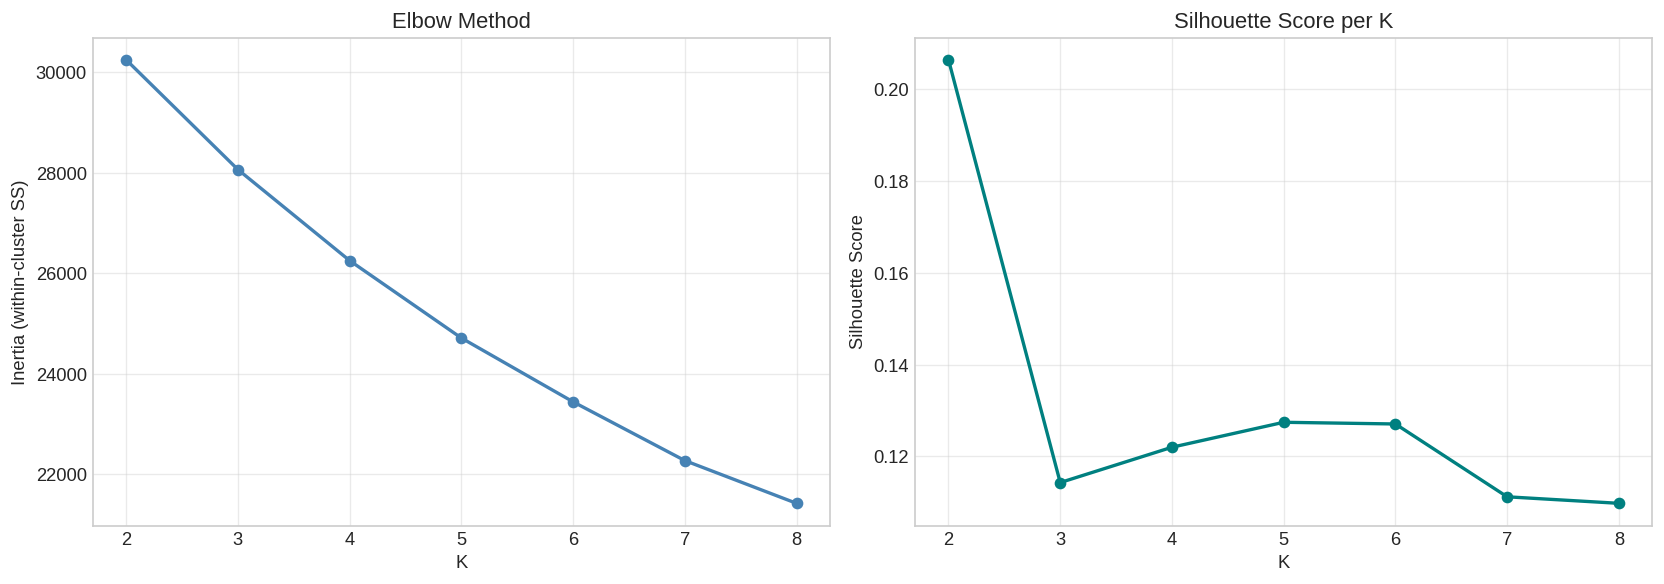

Silhouette peaks at K=2 (score=0.206)

All K scores:
K | Silhouette | DBI | CH
K=2: Silhouette=0.206, DBI=1.826, CH=599
K=3: Silhouette=0.114, DBI=2.118, CH=420
K=4: Silhouette=0.122, DBI=1.960, CH=356
K=5: Silhouette=0.127, DBI=1.835, CH=323
K=6: Silhouette=0.127, DBI=1.733, CH=299
K=7: Silhouette=0.111, DBI=1.810, CH=284
K=8: Silhouette=0.110, DBI=1.816, CH=267


In [125]:
# Run K-Means for K = 2..8, recording Inertia and Silhouette.
# Elbow = where inertia stops improving sharply.
# Silhouette = average (cohesion - separation) / max(cohesion, separation), range [-1, 1]; higher is better.
K_range = range(2, 9)
inertias, silhouettes, dbi_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))
    dbi_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'o-', color='steelblue', lw=2)
axes[0].set_xlabel('K')
axes[0].set_ylabel('Inertia (within-cluster SS)')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, silhouettes, 'o-', color='teal', lw=2)
axes[1].set_xlabel('K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K')

for ax in axes:
    ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '08_kmeans_k_selection.png'), dpi=150, bbox_inches='tight')
plt.show()

best_sil_k = list(K_range)[np.argmax(silhouettes)]
print(f'Silhouette peaks at K={best_sil_k} (score={max(silhouettes):.3f})')
print('\nAll K scores:')

print("K | Silhouette | DBI | CH")
for k, s, d, c in zip(K_range, silhouettes, dbi_scores, ch_scores):
    print(f"K={k}: Silhouette={s:.3f}, DBI={d:.3f}, CH={c:.0f}")

In [126]:
# ── K SELECTION DECISION ──
# Inspect Elbow and Silhouette plots above, then set K_CHOSEN.
# If the two methods agree: set K to the agreed value.
# If they disagree: try both, choose the K whose cluster profiles are more
# business-distinct (i.e., segments differ in actionable ways, not just statistically).
# Document the reasoning in the markdown cell below before submission.

K_CHOSEN = best_sil_k  # Update after inspecting plots
print(f'>>> K_CHOSEN = {K_CHOSEN}')

>>> K_CHOSEN = 2


**K Selection Reasoning:**

The Elbow plot shows inertia declining continuously from K=2 to K=8 with no sharp inflection — no single K stands out as geometrically optimal. The Silhouette plot provides a clear answer: score peaks at K=2 (0.206) and drops sharply to 0.114 at K=3, with only modest recovery thereafter. The dendrogram corroborates this: the only unambiguous cut is at Ward distance ≈50, producing two branches. The left branch has a lower maximum internal merge distance (≈33), indicating relatively homogeneous members; the right branch merges at ≈37, reflecting greater internal diversity.

Across the three quantitative metrics, Silhouette and CH both peak at K=2 (0.206 and 599 respectively). DBI favors K=6 (1.733) but the improvement over K=2 (1.826) is marginal while Silhouette at K=6 drops to 0.127 — 38% below its K=2 value. All signals considered, **K=2** is the most consistent and interpretable choice, producing a clean split between an engaged high-value segment and a low-engagement low-value segment.

In [127]:
# Final K-Means fit
km_final  = KMeans(n_clusters=K_CHOSEN, random_state=SEED, n_init=10)
labels_km = km_final.fit_predict(X)

print(f'K-Means K={K_CHOSEN}:')
print(pd.Series(labels_km).value_counts().sort_index().rename('households'))
print(f'Silhouette: {silhouette_score(X, labels_km):.3f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X, labels_km):.3f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X, labels_km):.0f}')

K-Means K=2:
0    1601
1     899
Name: households, dtype: int64
Silhouette: 0.206
Davies-Bouldin: 1.826
Calinski-Harabasz: 599


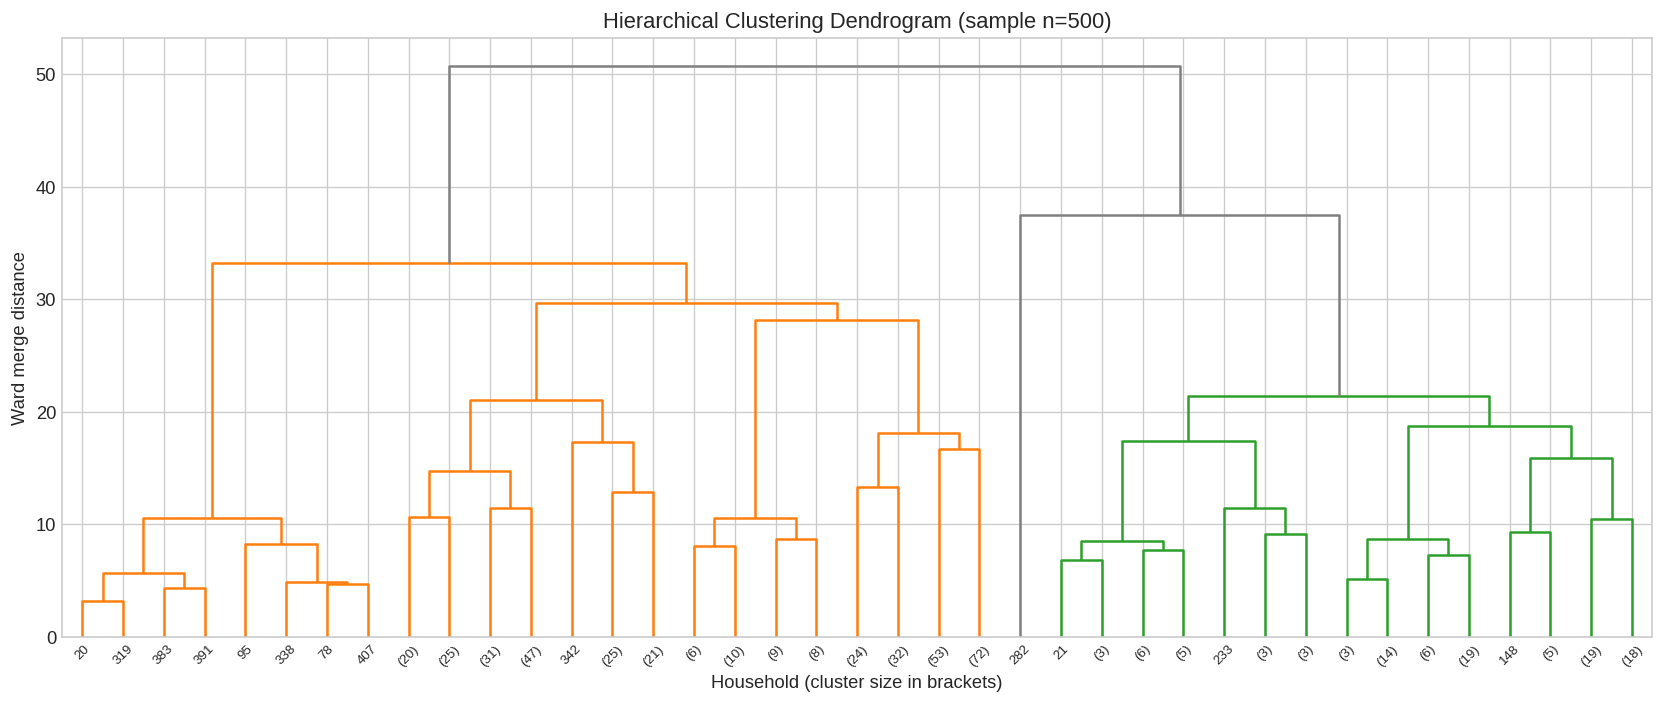

Hierarchical K=2:
0    1116
1    1384
Name: households, dtype: int64
Silhouette: 0.159
Davies-Bouldin: 2.062


In [128]:
# Hierarchical clustering with Ward linkage and same K for direct comparison.
# Dendrogram built on a 500-household sample for speed; full data used for final labels.
sample_idx = np.random.RandomState(SEED).choice(len(X), min(500, len(X)), replace=False)
Z = linkage(X[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='level', p=5,
           color_threshold=0.7 * max(Z[:, 2]),
           above_threshold_color='grey')
ax.set_title(f'Hierarchical Clustering Dendrogram (sample n={len(sample_idx)})')
ax.set_xlabel('Household (cluster size in brackets)')
ax.set_ylabel('Ward merge distance')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '09_dendrogram.png'), dpi=150, bbox_inches='tight')
plt.show()

hc_final  = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage='ward')
labels_hc = hc_final.fit_predict(X)

print(f'Hierarchical K={K_CHOSEN}:')
print(pd.Series(labels_hc).value_counts().sort_index().rename('households'))
print(f'Silhouette: {silhouette_score(X, labels_hc):.3f}')
print(f'Davies-Bouldin: {davies_bouldin_score(X, labels_hc):.3f}')

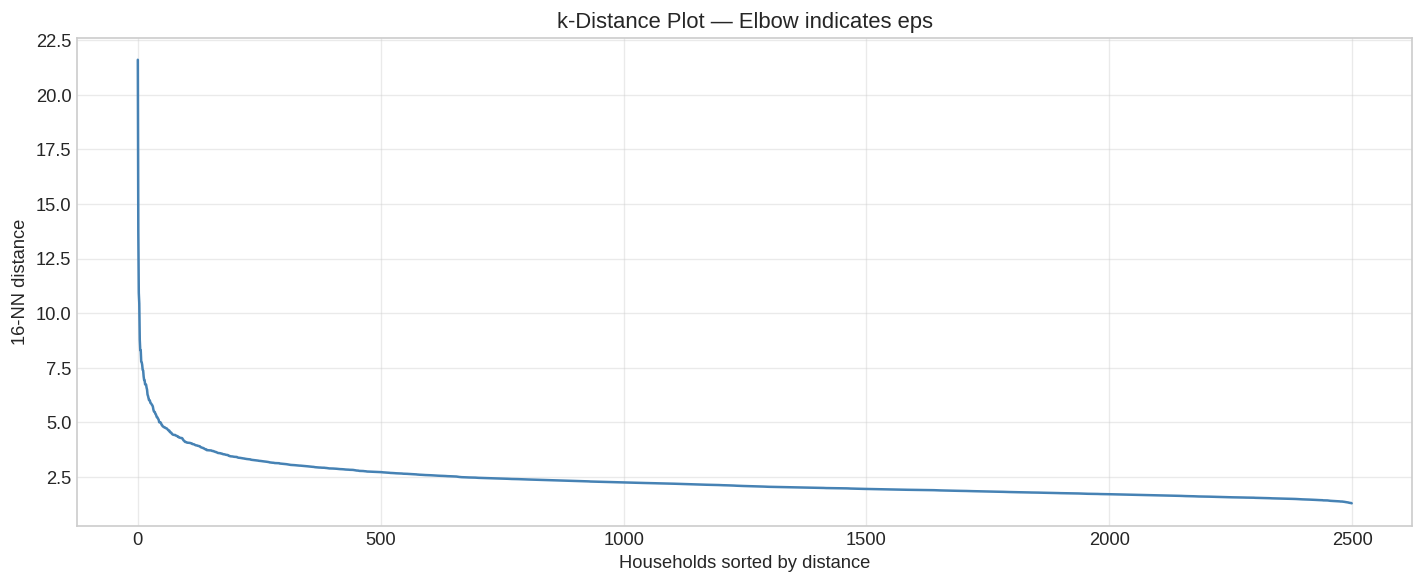

min_samples = 16 | Set EPS from elbow above


In [129]:
# DBSCAN: k-distance plot to select eps.
# The elbow of the k-distance curve marks the boundary between dense regions
# (core points) and sparse regions (noise). min_samples = n_features + 1 per Ester et al. (1996).
MIN_SAMPLES = len(df_features.columns) + 1
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(k_distances, color='steelblue')
ax.set_xlabel('Households sorted by distance')
ax.set_ylabel(f'{MIN_SAMPLES}-NN distance')
ax.set_title('k-Distance Plot — Elbow indicates eps')
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '10_dbscan_kdist.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'min_samples = {MIN_SAMPLES} | Set EPS from elbow above')

In [130]:
# Set EPS based on the elbow in the k-distance plot above.
EPS = 4.5  # Update after inspecting k-distance plot

db_final  = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
labels_db = db_final.fit_predict(X)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = (labels_db == -1).sum()

print(f'DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}):')
print(f'  Clusters found: {n_clusters_db}')
print(f'  Noise points: {n_noise} ({n_noise/len(labels_db)*100:.1f}%)')
print(pd.Series(labels_db).value_counts().sort_index().rename('count'))

valid = labels_db != -1
if valid.sum() > 10 and len(set(labels_db[valid])) > 1:
    print(f'  Silhouette (non-noise): {silhouette_score(X[valid], labels_db[valid]):.3f}')

DBSCAN (eps=4.5, min_samples=16):
  Clusters found: 1
  Noise points: 25 (1.0%)
-1      25
 0    2475
Name: count, dtype: int64


In [143]:
# ── Evaluation Summary ──
# ARI measures agreement between two clustering solutions, corrected for chance.
# ARI = 1: perfect agreement. ARI = 0: no better than random.
# High ARI between K-Means and Hierarchical indicates the cluster structure is
# algorithmically robust — it exists in the data, not just in one method's assumptions.
ari_km_hc = adjusted_rand_score(labels_km, labels_hc)
ari_km_db = adjusted_rand_score(labels_km, labels_db)
ari_hc_db = adjusted_rand_score(labels_hc, labels_db)

print('=' * 50)
print('ALGORITHM COMPARISON')
print('=' * 50)

eval_rows = [
    ['K-Means',       K_CHOSEN,       round(silhouette_score(X, labels_km), 3),
                                       round(davies_bouldin_score(X, labels_km), 3),
                                       round(calinski_harabasz_score(X, labels_km), 0)],
    ['Hierarchical',  K_CHOSEN,       round(silhouette_score(X, labels_hc), 3),
                                       round(davies_bouldin_score(X, labels_hc), 3),
                                       round(calinski_harabasz_score(X, labels_hc), 0)],
]
if valid.sum() > 10 and len(set(labels_db[valid])) > 1:
    eval_rows.append(['DBSCAN', n_clusters_db,
                      round(silhouette_score(X[valid], labels_db[valid]), 3),
                      round(davies_bouldin_score(X[valid], labels_db[valid]), 3), 'N/A'])

eval_df = pd.DataFrame(eval_rows, columns=['Algorithm', 'K', 'Silhouette \u2191', 'DBI \u2193', 'CH \u2191'])
print(eval_df.to_string(index=False))

print(f'\nAdjusted Rand Index:')
print(f'  K-Means  \u2194 Hierarchical : {ari_km_hc:.3f}')
print(f'  K-Means  \u2194 DBSCAN       : {ari_km_db:.3f}')
print(f'  Hierarchical \u2194 DBSCAN   : {ari_hc_db:.3f}')

# ── PCA-reduced clustering comparison ──
pca = PCA(n_components=8, random_state=SEED)
X_pca8 = pca.fit_transform(X)
km_pca8 = KMeans(n_clusters=2, random_state=SEED, n_init=10).fit_predict(X_pca8)

print(f'\nPCA8 K=2: Silhouette={silhouette_score(X_pca8, km_pca8):.3f}, '
      f'DBI={davies_bouldin_score(X_pca8, km_pca8):.3f}')
print(f'ARI (Full 15D vs PCA8): {adjusted_rand_score(labels_km, km_pca8):.3f}')

random_labels = np.random.RandomState(SEED).randint(0, 2, len(X))
print(f'Random baseline Silhouette: {silhouette_score(X, random_labels):.3f}')

# Save labels
df_clusters = df_features.copy()
df_clusters['cluster_km'] = labels_km
df_clusters['cluster_hc'] = labels_hc
df_clusters['cluster_db'] = labels_db
df_clusters['is_noise_dbscan'] = (labels_db == -1)
df_clusters.to_csv(os.path.join(OUTPUT_DIR, 'df_clusters.csv'))
print('\ndf_clusters.csv saved')

ALGORITHM COMPARISON
   Algorithm  K  Silhouette ↑  DBI ↓  CH ↑
     K-Means  2         0.206  1.826 599.0
Hierarchical  2         0.159  2.062 487.0

Adjusted Rand Index:
  K-Means  ↔ Hierarchical : 0.552
  K-Means  ↔ DBSCAN       : 0.003
  Hierarchical ↔ DBSCAN   : 0.001

PCA8 K=2: Silhouette=0.236, DBI=1.641
ARI (Full 15D vs PCA8): 0.992
Random baseline Silhouette: 0.000

df_clusters.csv saved


## 6. Cluster Profiling

K-Means is selected as the primary algorithm for profiling. Centroids are directly interpretable as the mean household in each cluster — a natural archetype for persona construction. The ARI check above confirms whether Hierarchical clustering recovers the same structure.

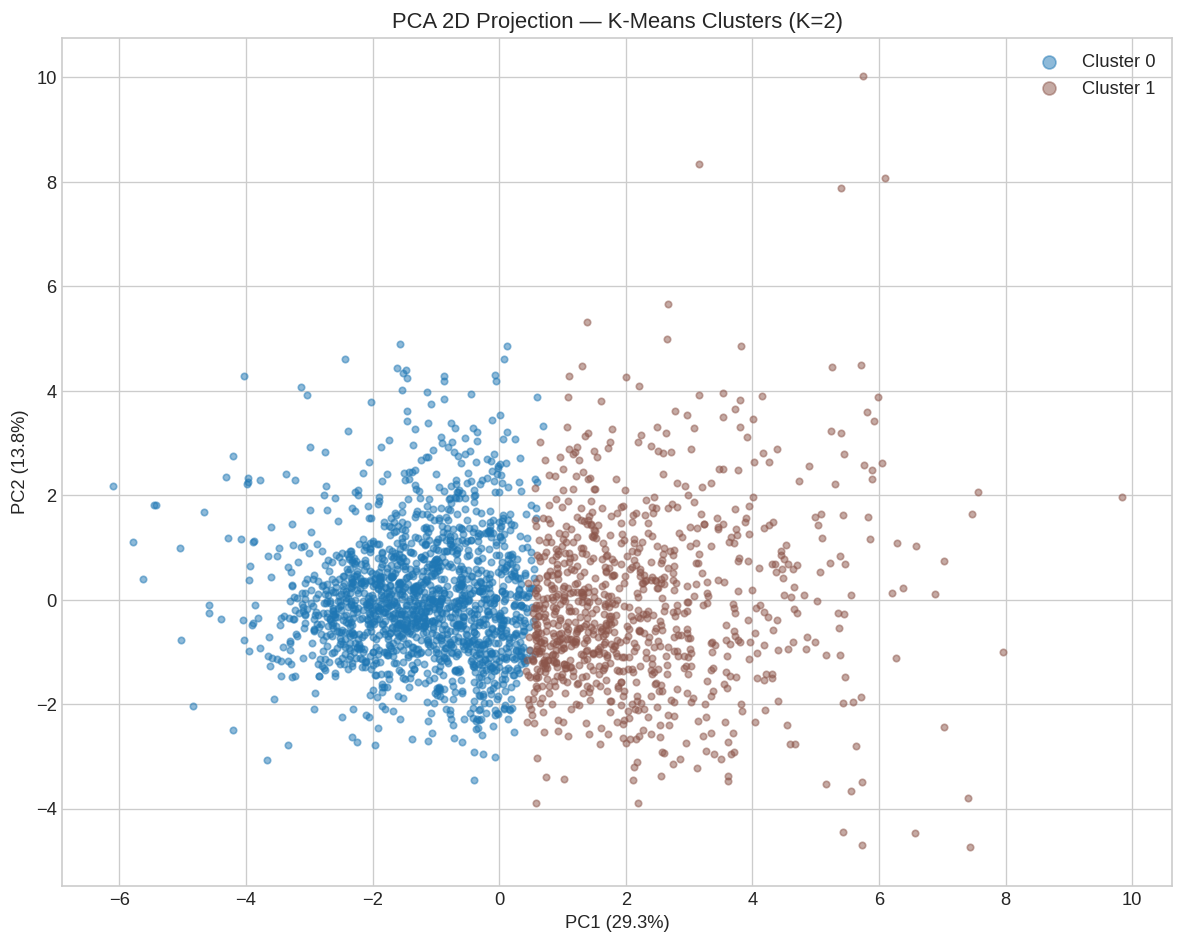

In [132]:
# PCA 2D projection: preserves global (Euclidean) distances.
colors = plt.cm.tab10(np.linspace(0, 0.5, K_CHOSEN))
pca2   = PCA(n_components=2, random_state=SEED)
X_pca  = pca2.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(K_CHOSEN):
    mask = labels_km == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[colors[c]], label=f'Cluster {c}', alpha=0.5, s=15)
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title(f'PCA 2D Projection — K-Means Clusters (K={K_CHOSEN})')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '11_pca_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

Running t-SNE...


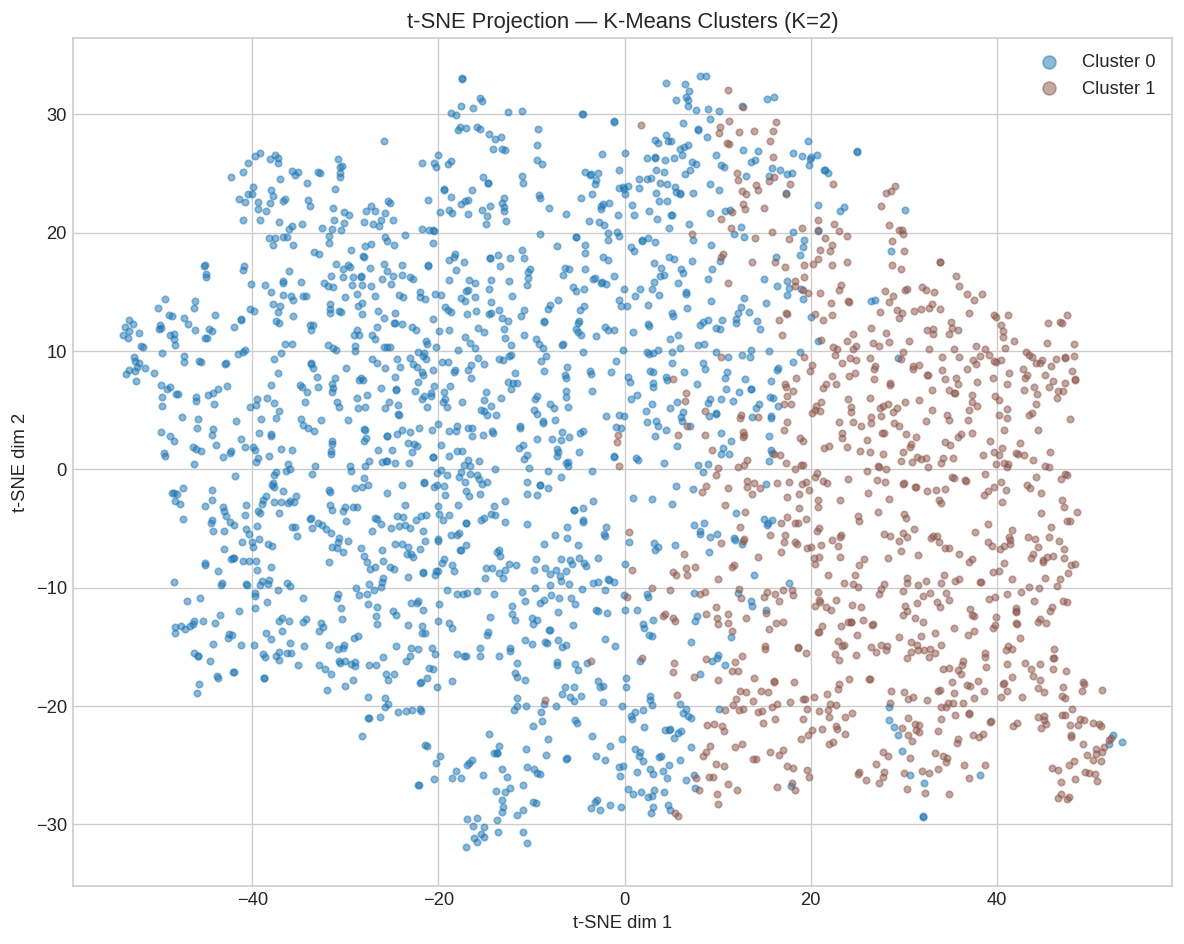

In [133]:
# t-SNE projection: better reveals non-linear cluster boundaries that PCA may miss.
print('Running t-SNE...')
X_tsne = TSNE(n_components=2, random_state=SEED, perplexity=40, n_iter=1000).fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 8))
for c in range(K_CHOSEN):
    mask = labels_km == c
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=[colors[c]], label=f'Cluster {c}', alpha=0.5, s=15)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.set_title(f't-SNE Projection — K-Means Clusters (K={K_CHOSEN})')
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '12_tsne_clusters.png'), dpi=150, bbox_inches='tight')
plt.show()

In [134]:
# Per-cluster feature means
profile = df_clusters.groupby('cluster_km')[df_features.columns].mean()
print('Cluster Profiles (raw feature means):')
print(profile.round(3).T.to_string())

Cluster Profiles (raw feature means):
cluster_km                      0         1
recency                    36.033     6.953
frequency                  58.896   201.612
monetary                 1405.711  6459.310
avg_basket_value           27.687    38.924
avg_basket_size           452.984  1222.007
std_basket_value           25.345    34.856
n_unique_departments       10.477    15.472
category_hhi                0.362     0.319
national_brand_ratio        0.703     0.721
discount_rate               0.156     0.143
coupon_redemption_rate      0.001     0.016
campaign_exposure_count     1.021     6.199
active_weeks_ratio          0.350     0.728
spending_trend_slope       -0.003     0.098
primary_store_share         0.707     0.714


In [135]:
# Cluster signatures: top deviating features per cluster, expressed as z-scores
# relative to the global mean. These are the fingerprints used to name each cluster.
global_mean = df_features.mean()
global_std  = df_features.std().replace(0, 1)
z_scores    = (profile - global_mean) / global_std

print('CLUSTER SIGNATURES — Top 3 deviating features (z-score from global mean)')
print('=' * 65)
for c in range(K_CHOSEN):
    top3 = z_scores.loc[c].abs().nlargest(3)
    size = sum(labels_km == c)
    print(f'\nCluster {c} (n={size}, {size/len(labels_km)*100:.1f}%):')
    for feat in top3.index:
        direction = '\u2191 HIGH' if z_scores.loc[c, feat] > 0 else '\u2193 LOW'
        print(f'  {direction}  {feat}: z={z_scores.loc[c, feat]:.2f}')

CLUSTER SIGNATURES — Top 3 deviating features (z-score from global mean)

Cluster 0 (n=1601, 64.0%):
  ↓ LOW  campaign_exposure_count: z=-0.57
  ↓ LOW  active_weeks_ratio: z=-0.54
  ↓ LOW  monetary: z=-0.54

Cluster 1 (n=899, 36.0%):
  ↑ HIGH  campaign_exposure_count: z=1.02
  ↑ HIGH  active_weeks_ratio: z=0.97
  ↑ HIGH  monetary: z=0.97


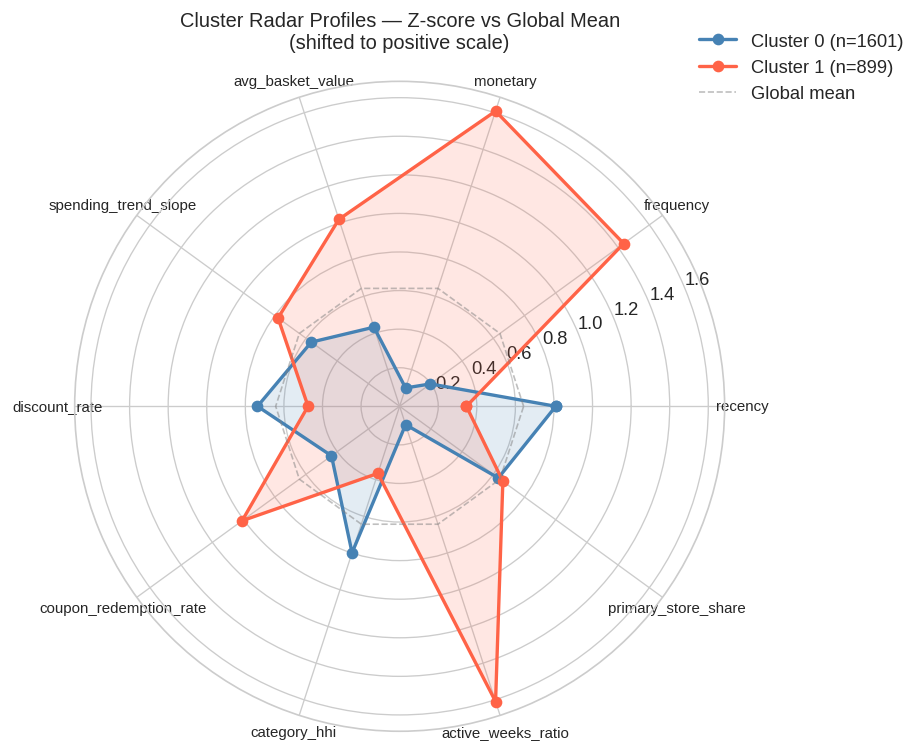

In [136]:
# Z-score radar — cả 2 cluster trên 1 chart
radar_features = ['recency', 'frequency', 'monetary', 'avg_basket_value',
                  'spending_trend_slope', 'discount_rate',
                  'coupon_redemption_rate', 'category_hhi',
                  'active_weeks_ratio', 'primary_store_share']

# Shift z-scores để không có giá trị âm
z_plot = z_scores[radar_features].copy()
shift = abs(z_plot.min().min()) + 0.1
z_plot = z_plot + shift

N = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

for c, color, label in zip([0, 1], ['steelblue', 'tomato'],
                            ['Cluster 0 (n=1601)', 'Cluster 1 (n=899)']):
    vals = z_plot.loc[c].tolist()
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', color=color, lw=2, label=label)
    ax.fill(angles, vals, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, size=9)
ax.set_title('Cluster Radar Profiles — Z-score vs Global Mean\n(shifted to positive scale)',
             size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Thêm reference ring tại shift value (= global mean line)
mean_ring = [shift] * (N + 1)
ax.plot(angles, mean_ring, '--', color='grey', lw=1, alpha=0.5, label='Global mean')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figures', '13_radar_profiles.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [137]:
# Demographic cross-validation: income and household composition by cluster.
# Coverage is ~32%, so findings are indicative, not conclusive.
demo_clean = demo.copy()
demo_clean.columns = demo_clean.columns.str.lower()

# Verify join key exists after lowercasing
assert 'household_key' in demo_clean.columns, f'Expected household_key, got: {list(demo_clean.columns)}'

demo_joined = (df_clusters[['cluster_km']]
               .reset_index()
               .merge(demo_clean, on='household_key', how='left'))

coverage = demo_joined['income_desc'].notna().mean()
print(f'Demographic coverage: {coverage:.1%}')

if 'income_desc' in demo_joined.columns:
    income_ct  = demo_joined.groupby(['cluster_km', 'income_desc']).size().unstack(fill_value=0)
    income_pct = income_ct.div(income_ct.sum(axis=1), axis=0).round(2)
    print('\nIncome distribution by cluster (% of households with demographic data):')
    print(income_pct.to_string())

Demographic coverage: 32.0%

Income distribution by cluster (% of households with demographic data):
income_desc  100-124K  125-149K  15-24K  150-174K  175-199K  200-249K  25-34K  250K+  35-49K  50-74K  75-99K  Under 15K
cluster_km                                                                                                             
0                0.03      0.02    0.12      0.02      0.01      0.00    0.12   0.00    0.24    0.24    0.11       0.08
1                0.05      0.06    0.08      0.05      0.02      0.01    0.09   0.02    0.20    0.24    0.12       0.07


## 7. Results & Business Recommendations

We identify **K=2** distinct household segments with a K-Means Silhouette score of **0.206** and moderate inter-algorithm stability (ARI=0.552 between K-Means and Hierarchical). The cluster structure is real but has soft boundaries — both algorithms independently recover the same two-group split, with disagreement concentrated at the boundary zone rather than the cluster cores.

| Cluster | Name | Size | Top Signal | Recommended Action | KPI |
|---|---|---|---|---|---|
| 0 | Passive Occasionals | 1,601 (64%) | Low frequency, low active_weeks_ratio, flat spending trend | Reactivation campaigns with low-cost incentives; personalized weekly offers to stimulate trip frequency | Trip frequency, active_weeks_ratio |
| 1 | Committed Regulars | 899 (36%) | High monetary, high frequency, positive spending_trend_slope | Loyalty reinforcement via VIP programs; category expansion cross-sell | Monetary growth, category breadth, retention rate |

**Cluster 0 — Passive Occasionals (n=1,601, 64%):** These households account for the majority of the base but generate only $1,406 on average in total spend — less than a quarter of Cluster 1's value. They shop infrequently (59 trips over two years, active in only 35% of weeks), have low campaign exposure (1.02 campaigns), and a near-zero spending trend slope (−0.003) indicating flat-to-declining engagement. Promotion sensitivity is slightly higher (discount rate 0.156 vs. 0.143) but coupon usage is near zero (0.001 redemptions per trip), suggesting passive rather than active deal-seeking. The recommended intervention is frequency stimulation through low-barrier, personalized incentives tied to categories they already purchase. Success is measured by change in active_weeks_ratio and trip frequency over the following quarter.

**Cluster 1 — Committed Regulars (n=899, 36%):** These households are the retailer's core revenue asset, generating $6,459 on average — 4.6× Cluster 0. With 202 shopping trips over two years they shop roughly every 3–4 days, are active in 73% of all weeks, and carry a positive spending trend slope (0.098) indicating growing engagement. Their below-average discount rate (0.143) and relatively higher coupon usage (0.016 per trip) suggest loyalty rather than deal-seeking drives behavior. The recommended strategy is two-pronged: loyalty reinforcement through VIP recognition programs that reward existing behavior without margin-eroding discounts, and category expansion cross-sell targeting the gap between their current 15.5 active departments and the full category range. Success is measured by retention rate, total monetary growth, and number of active departments per household.

## 8. Limitations & Future Work

**Limitations:**
- No ground truth: cluster validity is assessed through interpretability and metric scores, not known labels. Different feature sets would produce different — but equally valid — segmentations.
- Demographic coverage: ~40% of households lack demographic data, limiting post-hoc profile enrichment.
- Static snapshot: the 2-year window produces a fixed segmentation. In practice households migrate between segments as behavior evolves.
- Silhouette and DBI measure geometric quality, not business relevance.

**Future Work:**
- Gaussian Mixture Models for soft (probabilistic) cluster membership at boundaries.
- Rolling temporal segmentation to track lifecycle transitions.
- Use cluster labels as features in a churn prediction model.


In [138]:
print('Pipeline complete. Output files:')
print(f'  {OUTPUT_DIR}/df_features.csv')
print(f'  {OUTPUT_DIR}/df_clusters.csv')
for f in sorted(os.listdir(os.path.join(OUTPUT_DIR, 'figures'))):
    print(f'  {OUTPUT_DIR}/figures/{f}')

Pipeline complete. Output files:
  /content/drive/MyDrive/da_final/dunnhumby/output_files/df_features.csv
  /content/drive/MyDrive/da_final/dunnhumby/output_files/df_clusters.csv
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/01_spend_frequency_dist.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/02_weekly_trend.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/03_department_spend.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/04_rfm_scatter.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/05_promotion_behavior.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/06_correlation_heatmap.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/07_pca_scree.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/08_kmeans_k_selection.png
  /content/drive/MyDrive/da_final/dunnhumby/output_files/figures/09_dendrogram.png
  /content/drive/MyDrive/da_fin